<a href="https://colab.research.google.com/github/joashpark/college-football-predictor/blob/main/College_Football_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
import pandas as pd

df = pd.read_csv("cfb_box-scores_2002-2025.csv")

In [8]:
df.head()

,season,week,date,time_et,game_type,away,home,rank_away,rank_home,conf_away,...,int_away,int_home,pen_num_away,pen_yards_away,pen_num_home,pen_yards_home,possession_away,possession_home,attendance,tv
0,2002,1.0,2002-08-22,7:30 PM,regular,Colorado State,Virginia,NaN,NaN,mwc,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57120.0,NaN
1,2002,1.0,2002-08-23,8:00 PM,regular,Fresno State,Wisconsin,NaN,25.0,wac,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75136.0,NaN
2,2002,1.0,2002-08-24,2:30 PM,regular,Texas Tech,Ohio State,NaN,13.0,big12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100037.0,NaN
3,2002,1.0,2002-08-24,4:30 PM,regular,New Mexico,NC State,NaN,NaN,mwc,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47018.0,NaN
4,2002,1.0,2002-08-24,7:45 PM,regular,Arizona State,Nebraska,NaN,10.0,pac12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77779.0,NaN


In [9]:
df.columns

Index(['season', 'week', 'date', 'time_et', 'game_type', 'away', 'home',
       'rank_away', 'rank_home', 'conf_away', 'conf_home', 'neutral',
       'score_away', 'score_home', 'q1_away', 'q2_away', 'q3_away', 'q4_away',
       'ot_away', 'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home',
       'first_downs_away', 'first_downs_home', 'third_down_comp_away',
       'third_down_att_away', 'third_down_comp_home', 'third_down_att_home',
       'fourth_down_comp_away', 'fourth_down_att_away',
       'fourth_down_comp_home', 'fourth_down_att_home', 'pass_comp_away',
       'pass_att_away', 'pass_yards_away', 'pass_comp_home', 'pass_att_home',
       'pass_yards_home', 'rush_att_away', 'rush_yards_away', 'rush_att_home',
       'rush_yards_home', 'total_yards_away', 'total_yards_home', 'fum_away',
       'fum_home', 'int_away', 'int_home', 'pen_num_away', 'pen_yards_away',
       'pen_num_home', 'pen_yards_home', 'possession_away', 'possession_home',
       'attendance', 'tv'],
      dt

In [10]:
df['home_win'] = (df['score_home'] > df['score_away']).astype(int)

In [32]:
home = df[['home', 'score_home', 'score_away', 'recency_weight']].copy()
away = df[['away', 'score_away', 'score_home', 'recency_weight']].copy()

home.columns = ['team', 'points_for', 'points_against', 'weight']
away.columns = ['team', 'points_for', 'points_against', 'weight']

teams = pd.concat([home, away])

team_ratings = teams.groupby('team').apply(
    lambda x: ( (x['points_for'] - x['points_against']) * x['weight'] ).sum() / x['weight'].sum()
)

/tmp/ipykernel_17010/131818405.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_ratings = teams.groupby('team').apply(


In [16]:
predict("Georgia", "Florida")

'Georgia'

In [33]:
teams_list = pd.concat([df['home'], df['away']]).unique()
ratings = {team: 1500 for team in teams_list}

In [42]:
K = 20

for _, row in df.iterrows():
    home = row['home']
    away = row['away']

    home_rating = ratings[home]
    away_rating = ratings[away]

    expected_home = 1 / (1 + 10 ** ((away_rating - home_rating) / 400))
    actual_home = row['home_win']

    # strength adjustment
    margin = row['score_home'] - row['score_away']
    margin_factor = min(abs(margin) / 14, 1.5)

    ratings[home] += K * margin_factor * (actual_home - expected_home)
    ratings[away] += K * margin_factor * ((1 - actual_home) - (1 - expected_home))

In [43]:
conf_strength = df.groupby('conf_home')['home_win'].mean()

In [44]:
def conf_adjust(team_conf):
    return conf_strength.get(team_conf, 0.5)

In [46]:
df['upset'] = ((df['home_win'] == 1) & (df['home'] < df['away'])) | \
              ((df['home_win'] == 0) & (df['away'] < df['home']))

In [47]:
print("Model Accuracy:", accuracy)

Model Accuracy: 0.6848258831829864


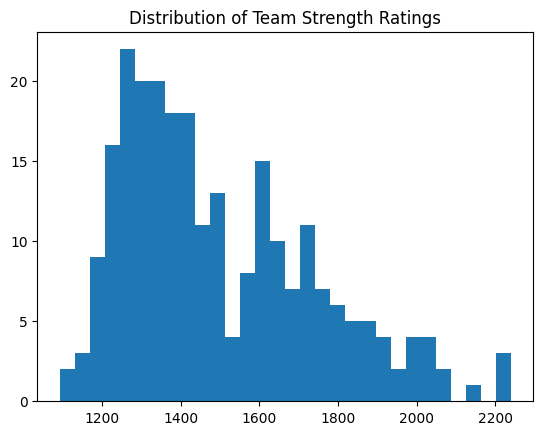

In [48]:
import matplotlib.pyplot as plt

plt.hist(list(ratings.values()), bins=30)
plt.title("Distribution of Team Strength Ratings")
plt.show()

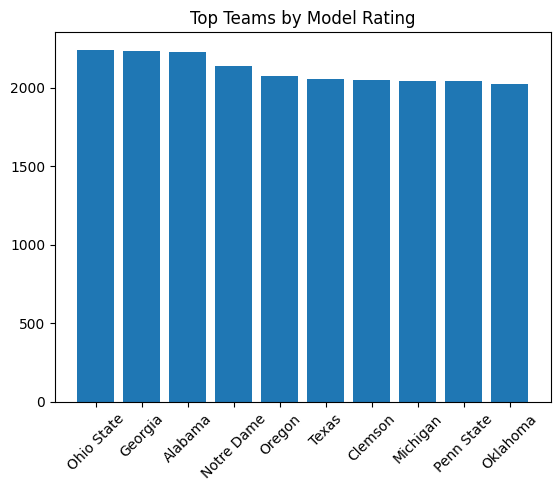

In [49]:
top_teams = sorted(ratings.items(), key=lambda x: x[1], reverse=True)[:10]

names = [t[0] for t in top_teams]
values = [t[1] for t in top_teams]

plt.bar(names, values)
plt.xticks(rotation=45)
plt.title("Top Teams by Model Rating")
plt.show()

In [35]:
sorted(ratings.items(), key=lambda x: x[1], reverse=True)[:10]

[('Georgia', 2048.2621183359975),
 ('Ohio State', 2024.8284269061558),
 ('Alabama', 2008.9160341811614),
 ('Oregon', 1940.7352485485699),
 ('Notre Dame', 1937.3961595798903),
 ('Michigan', 1900.572509449879),
 ('Texas', 1894.050159505208),
 ('Ole Miss', 1877.680811400216),
 ('Clemson', 1855.3940289926834),
 ('Oklahoma', 1852.111706090796)]

In [36]:
def predict(home, away):
    prob = 1 / (1 + 10 ** ((ratings[away] - ratings[home]) / 400))
    return home if prob > 0.5 else away

In [22]:
df['prediction'] = df.apply(
    lambda row: predict(row['home'], row['away']),
    axis=1
)

df['correct'] = df['prediction'] == df['home'].where(df['home_win'] == 1, df['away'])

accuracy = df['correct'].mean()
print(accuracy)

0.6848258831829864


In [23]:
import numpy as np

def win_probability(home_team, away_team):
    diff = (team_ratings[home_team] + home_advantage) - team_ratings[away_team]
    return 1 / (1 + np.exp(-diff))

In [24]:
win_probability("Georgia", "Florida")

np.float64(0.9999957183353924)

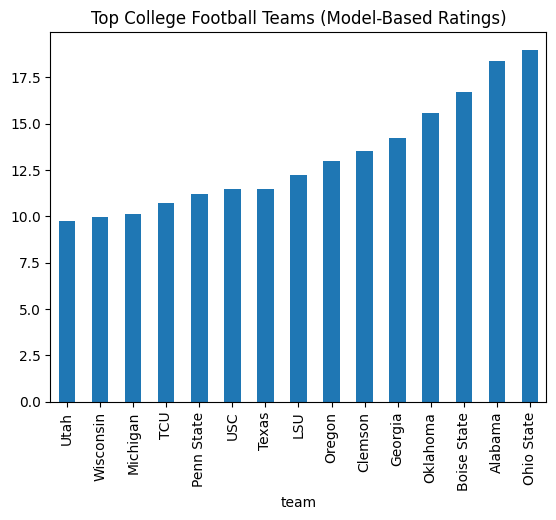

In [25]:
import matplotlib.pyplot as plt

team_ratings.sort_values().tail(15).plot(kind='bar')
plt.title("Top College Football Teams (Model-Based Ratings)")
plt.show()

In [21]:
def predict(home_team, away_team):
    home_score = team_ratings[home_team] + home_advantage
    away_score = team_ratings[away_team]

    if home_score > away_score:
        return home_team
    else:
        return away_team

In [19]:
home_advantage = (df['score_home'] - df['score_away']).mean()

In [20]:
home_win_rate = df['home_win'].mean()
print(home_win_rate)
home_advantage = df['score_home'].sub(df['score_away']).mean()
print(home_advantage)

0.6234944312855919
7.232878093030288


In [26]:
win_probability("Ohio State", "Florida")

np.float64(0.9999999632557925)

In [27]:
predict("Ohio State", "Wisconsin")

'Ohio State'

In [28]:
df['predicted_home_win_prob'] = df.apply(
    lambda row: win_probability(row['home'], row['away']),
    axis=1
)

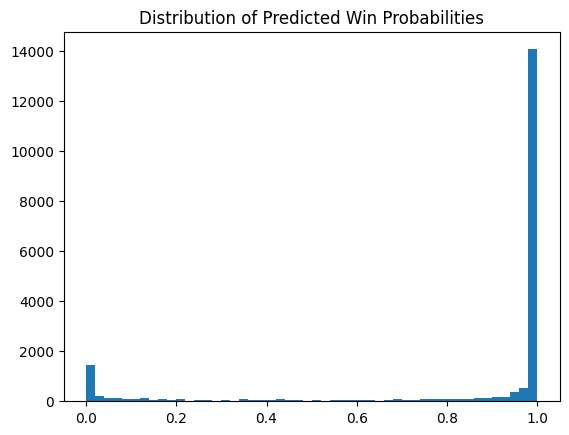

In [29]:
import matplotlib.pyplot as plt

plt.hist(df['predicted_home_win_prob'], bins=50)
plt.title("Distribution of Predicted Win Probabilities")
plt.show()

In [30]:
df['recency_weight'] = df['season'] - df['season'].min() + 1

In [37]:
import random

def simulate_game(home, away):
    prob = 1 / (1 + 10 ** ((ratings[away] - ratings[home]) / 400))
    return home if random.random() < prob else away

In [38]:
wins = {}

for team in teams_list:
    wins[team] = 0

for _, row in df.sample(500).iterrows():  # sample for speed
    winner = simulate_game(row['home'], row['away'])
    wins[winner] += 1

In [39]:
sorted(wins.items(), key=lambda x: x[1], reverse=True)[:10]

[('Boise State', 11),
 ('TCU', 11),
 ('Florida State', 9),
 ('North Texas', 9),
 ('South Alabama', 9),
 ('Oregon', 8),
 ('Oklahoma', 8),
 ('Ohio State', 7),
 ('NC State', 7),
 ('BYU', 7)]

In [40]:
import pandas as pd

opponent_strength = {}

In [41]:
df['home_opponent_rating'] = df['away'].map(ratings)
df['away_opponent_rating'] = df['home'].map(ratings)